# Morphology analysis of distributions

___

The statistical properties of a phase or point distribution can be studied beyond its reciprocal space by analysing the shapes of each detected object/void. This is possible with the `Morphology` class available in the Statistics module. For more details on this topic, see https://morphometry.org/theory/anisotropy-analysis-by-imt for reference.

In this notebook, we shall generate a point distribution and use it to understand the morphological features of various phase distributions that can be constructed from it. Since this class is only currently available for 2D distributions, the analysis here is also restricted to 2D.

In [1]:
import numpy as np
import meep as mp
import tostada as tost
import matplotlib.pyplot as plt

Using MPI version 4.1, 1 processes
GPU detected. Using CUDA.
GPU detected. Using CUDA.
GPU detected. Using CUDA


In [2]:
process = tost.Pointprocess(BoxSize=8,
                            diameter=0.24,
                            ax=0.3)
points = process.RandomSequentialAdsorption()

Estimated particles to be deposited=711 with mean inter-particle distance=0.3
number of experiments:1716320): |█████-------------------------| 17.2% Current FF=11.109 of 11.111


Since morphology is a property of the underlying distribution, it is available in both `PointDistribution` and `PhaseDistribution` using a `get_morphological_parameters` method. First, let us create a trivalent network from the above point distribution.

In [3]:
Mor = points.get_morphological_parameters(
                                        method='tri', #uses Delaunay triangulation to map points to phase
                                        rad=6 # dilation radius of walls (in pixels). 
                                        )

Volume fraction of generated phase = 0.637195079184727 with resolution = 0.009987515605493134
Morphology object created with method=tri


This creates a `Morphology` object. The generated phase distribution is used to detect polygons (arbitrarily shaped objects/voids) and their geometrical features. The phase distribution itself is also accessible within this class. The detected polygons can be visualized using `tostada.Visualize.plot_detected_polygons()`

<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

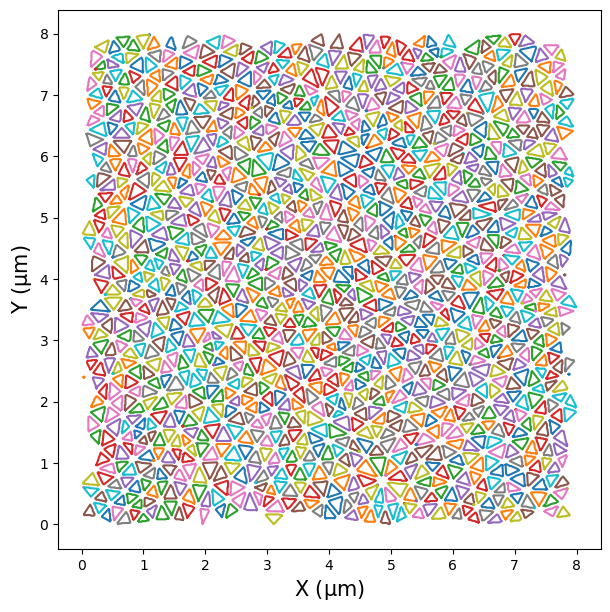

In [4]:
fig = tost.Visualize(points)

fig.plot_detected_polygons()

The original phase distribution was:

<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Z ($\\mathrm{\\mu}$m)'>

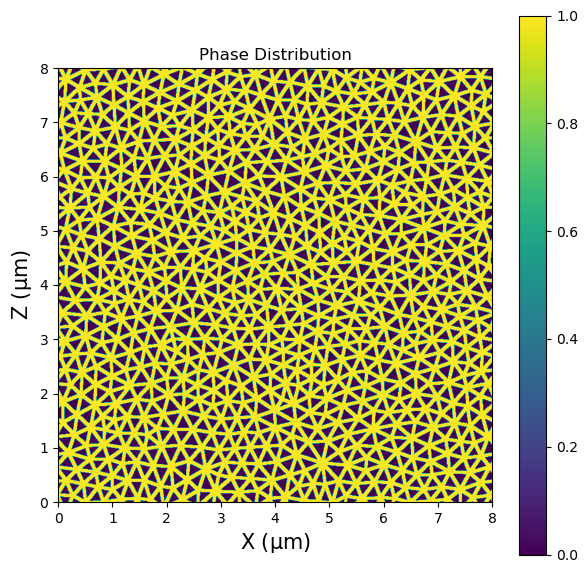

In [5]:
fig = tost.Visualize(points.morphology.distribution)
fig.plot_distribution()

Once initialized, the `Morphology` class generates Minkowski structure metrics for the system, accesible via `Morphology.psi`. For each detected polygon, it contains m values like $q_1,q_2,...q_m$ that characterize the local m-fold symmetry. Since the generated distribution is trivalent in nature, it should have high $q_3$ (and also $q_6$) but lower $q\neq3$.

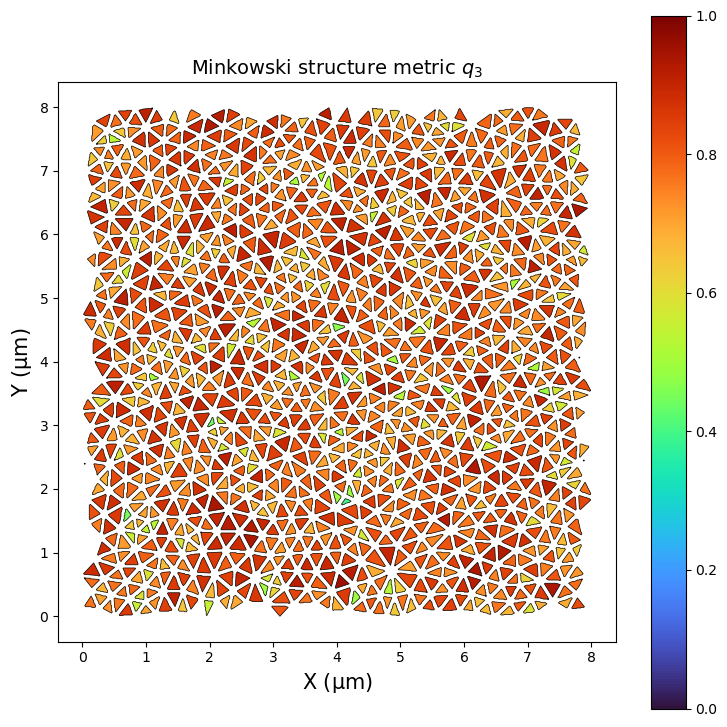

In [6]:
fig = tost.Visualize(points)
ax=fig.plot_structure_metric(s=3, # order of the Minkowski structure metric to be plotted for each polygon
                             skipind=2 #skips the first n polygons (simulation box and spurious edge(s))
                             )

<Axes: title={'center': 'Minkowski structure metric $q_4$'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mathrm{\\mu}}$m)'>

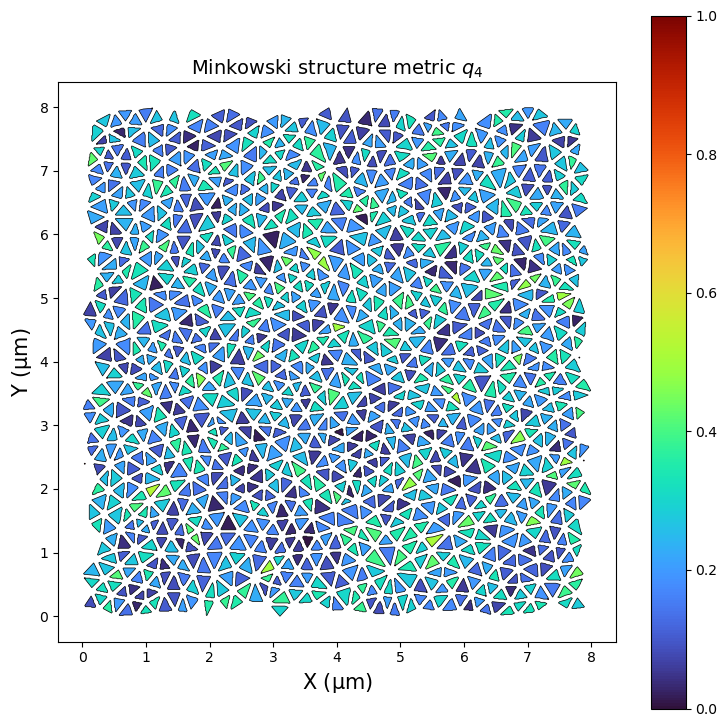

In [7]:
fig.plot_structure_metric(s=4,
                          skipind=2)

These visualizations can be summarized using `Morphology.get_morphology_stats()` method that computes the mean and standard deviation of each $q_m$.

Mean interfacial length = 0.5760524992633452+/-0.830419183460754


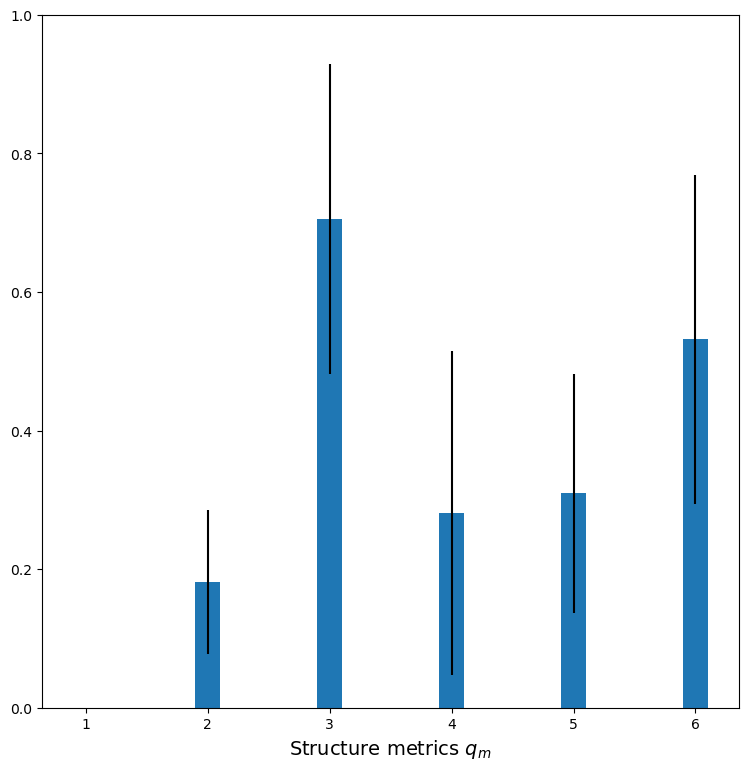

In [8]:
ax = points.morphology.get_morphology_stats()

The statistics confirm that $q_3$ is indeed higher than others indicating 3-fold symmetry in the distribution. For a stealthy disordered arrangements, this distinction is even more pronounced.

___

Now, let us create a circular pore system and analyze the same properties.

In [3]:
Mor = points.get_morphological_parameters(
                                        method='circle', #replaces points with pores of `self.diameter`
                                        )

Morphology object created with method=circle


<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

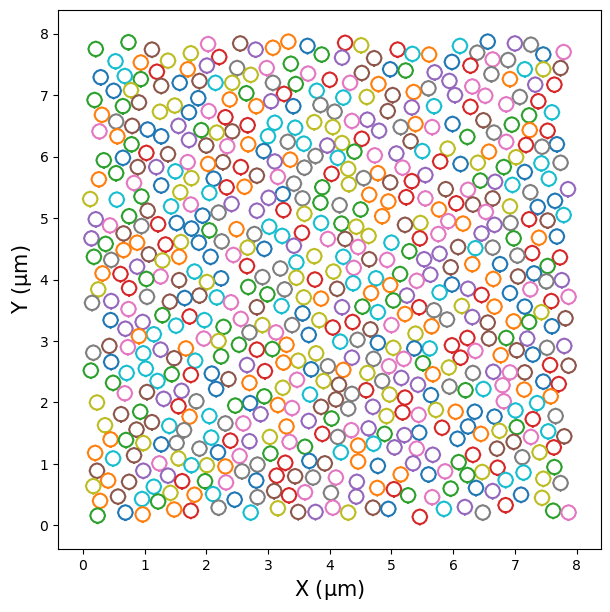

In [4]:
fig = tost.Visualize(points)

fig.plot_detected_polygons()

<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Z ($\\mathrm{\\mu}$m)'>

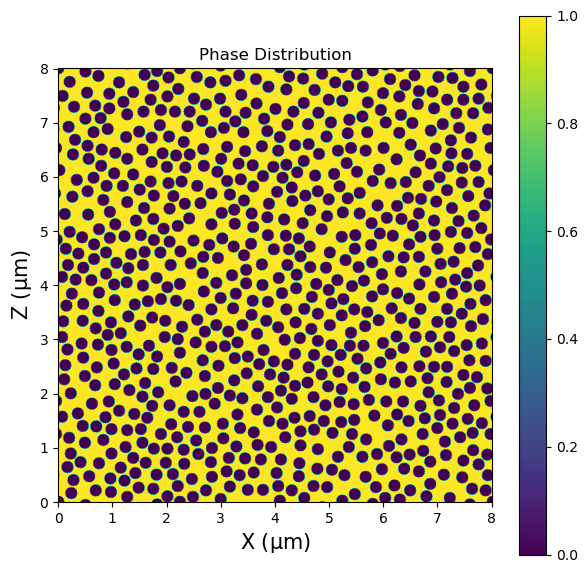

In [5]:
fig = tost.Visualize(points.morphology.distribution)
fig.plot_distribution()

Mean interfacial length = 0.7322385956066425+/-6.602513464528278e-15


<Axes: xlabel='Structure metrics $q_m$'>

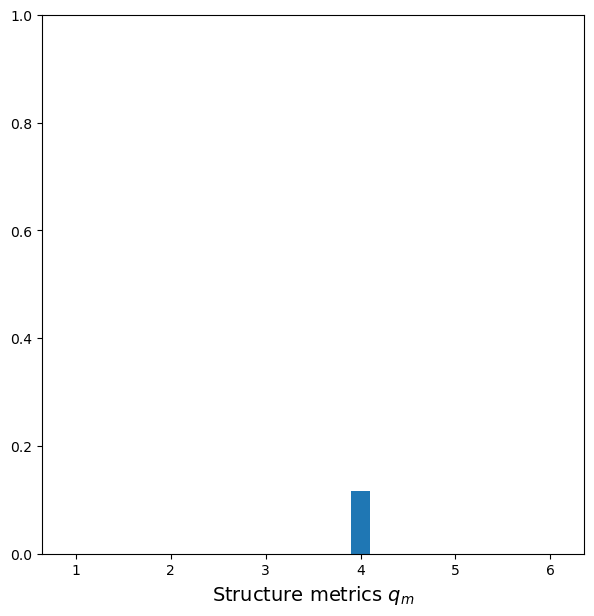

In [6]:
points.morphology.get_morphology_stats()

For circular objects, the only non-negative $q_m$ should be $q_1$ indicating closed polygons. However, $q_4$ appears to be slightly high. This is because circular objects are approximated by n-sided polygons and also because the computational domain choosen here is rather small for quick illustrations. For larger domains, this approaches zero too.

The un-normalized zeroth coefficient $\psi_1$ gives the perimeter of a given interface. Tostada saves this value for each polygon in `psi[:,0]` and so the mean statistics gives the mean perimeter of the objects/voids. For identical circles, this can be easily verified as $c = \pi d$.

In [9]:
Mor.mean_stats[0]/np.pi, points.diameter

(np.float64(0.2330787840269291), 0.24)

It is worth noting that this is not exactly equal only because of the low resolution (with respect to the diameter) used in creating the phase distribution. For high resolutions, this should closely match the input diameter.

___

Now, let us consider two different kinds of phase distribution. The first one is the Voronoi type distribution where the points are first tesselated using Voronoi networks and the network edges are dilated to yield a particular volume fraction. Next is a Centroidal Volume tesselation where before forming the voronoi tesselation, the point distribution is first relaxed using Llyod's algorithm (essentially points are slightly shifted until the polygon's center-of-mass roughly cooincides with the shifted points.)

In [21]:
Mor1 = points.get_morphological_parameters(
                                        method='vor', # maps points to net
                                        rad=6 # dilation radius of walls (in pixels). 
                                        )

Volume fraction of generated phase = 0.41722347689607714 with resolution = 0.009987515605493134
Morphology object created with method=vor


<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

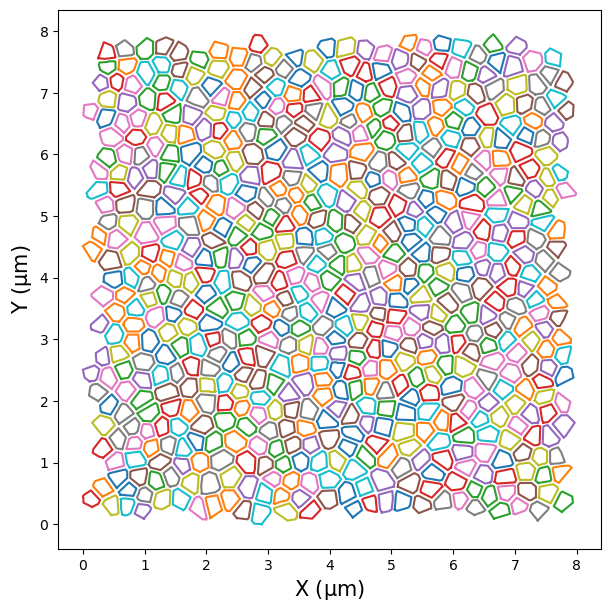

In [22]:
fig = tost.Visualize(points)
fig.plot_detected_polygons()

In [23]:
Mor2 = points.get_morphological_parameters(
                                        method='cvt', # maps points to net
                                        rad=6 # dilation radius of walls (in pixels). 
                                        )

Volume fraction of generated phase = 0.4066468100891364 with resolution = 0.009987515605493134
Morphology object created with method=cvt


<Axes: title={'center': 'Minkowski structure metric $q_6$'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mathrm{\\mu}}$m)'>

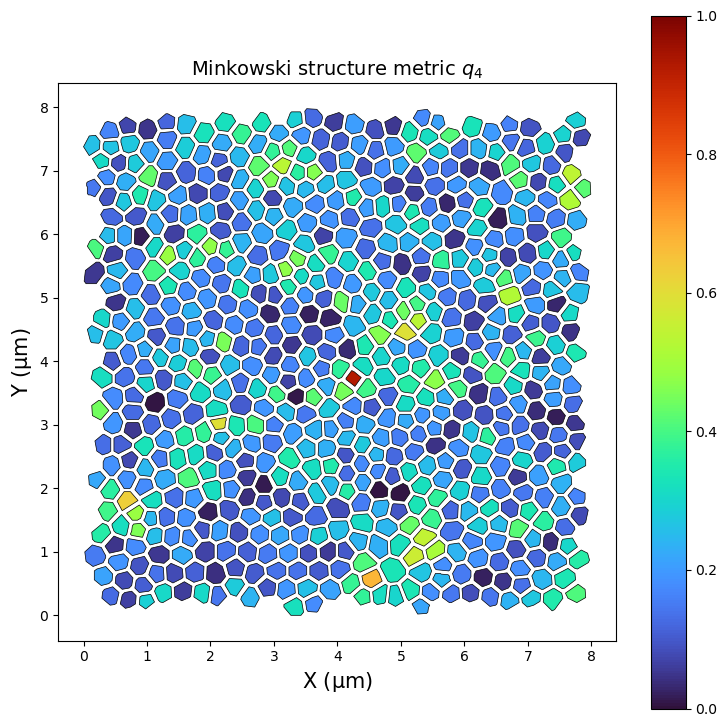

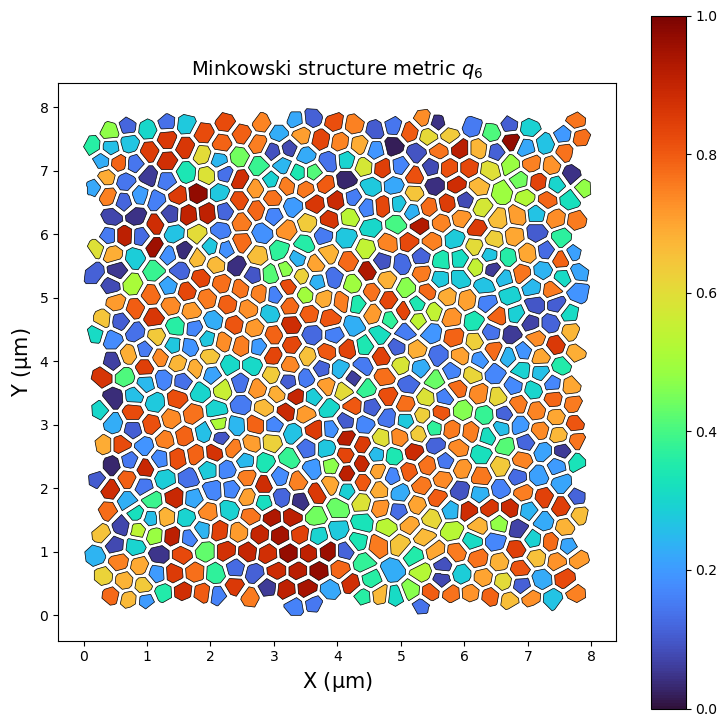

In [24]:
fig.plot_structure_metric(s=4,
                          skipind=2)
fig.plot_structure_metric(s=6,
                          skipind=2)

Mean interfacial length = 0.9128485947703108+/-0.07877028024105452
Mean interfacial length = 0.8946925211370291+/-0.07256688345699594


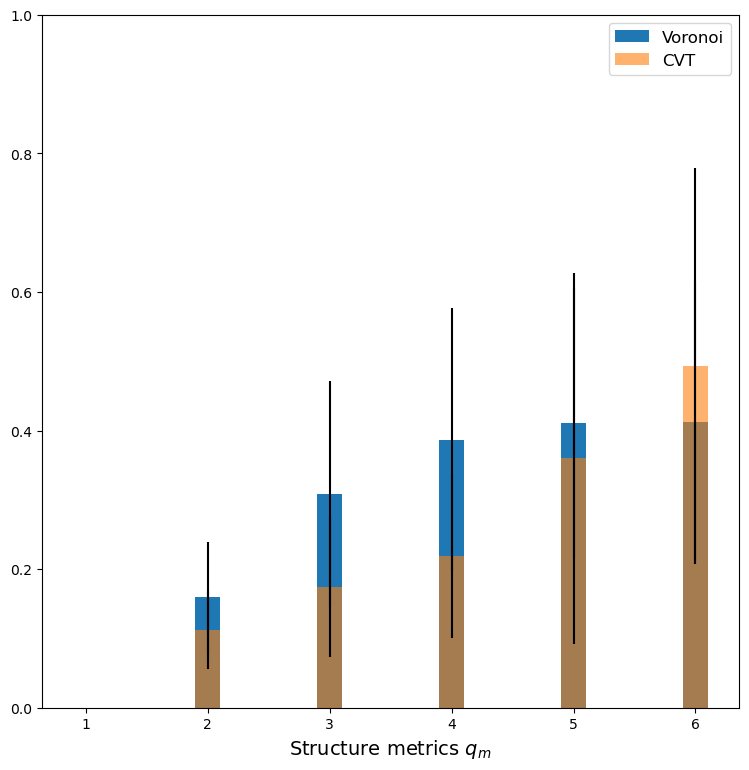

In [30]:
ax = Mor1.get_morphology_stats(label='Voronoi')
Mor2.get_morphology_stats(ax=ax,label='CVT',alpha=0.6)
ax.legend(fontsize=12)

It can clearly be seen that relaxing the point distribution before tesselation increases the "hexatic" order in the system while simultaneously decreasing $q_{m}$.